# Predicting Diabetes Progression: A Beginner-Friendly Data-Science Walkthrough

**Goal:** take a real public healthcare dataset from raw table to a simple, explainable prediction model, explaining every step along the way.

**Dataset:** *Diabetes progression study* - 442 diabetes patients, 10 baseline measurements (age, sex, BMI, blood pressure, six blood-serum tests) and one outcome: a score of **disease progression one year later**. Source: Efron, Hastie, Johnstone & Tibshirani (2004), *Least Angle Regression*, Annals of Statistics; data page: <https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html>. It is bundled with scikit-learn, so no download is needed.

**Roadmap**

| Step | What happens |
|---|---|
| 1 | Load the raw data |
| 2 | Audit it (types, missing values, duplicates) |
| 3 | Clean it (names, types, impossible values, missing values) |
| 4 | Detect and decide what to do about outliers |
| 5 | Save the cleaned dataset |
| 6 | Exploratory analysis with four key insights |
| 7 | Build and evaluate a lightweight regression model |
| 8 | Conclusions and limitations |

**How to run:** `pip install -r requirements.txt`, then *Run All*. The notebook creates `data/` and `figures/` next to itself.

> Disclaimer: this is a learning project. It is **not** medical advice and must not be used for clinical decisions.

## Step 0 - Setup
Import the libraries, create output folders, and fix a random seed so results are reproducible. **pandas** handles tables, **NumPy** the maths, **Matplotlib** the charts.

In [1]:
# --- Standard library & third-party imports ---
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn is used ONLY for the dataset loader and the lightweight model (Step 7)
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Folders for outputs (created next to the notebook) ---
DATA_DIR = Path("data")
FIG_DIR = Path("figures")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# --- Reproducibility: fixed seed so everyone gets the same split and results ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Consistent plot style ---
BLUE, ORANGE, GREY, RED = "#2b6cb0", "#dd6b20", "#718096", "#c53030"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.labelsize": 10,
})
pd.set_option("display.precision", 2)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

## Step 1 - Load the raw data
We ask for `scaled=False` so we get real-world units (years, mg/dL) rather than the pre-standardised numbers scikit-learn returns by default. Standardised numbers are hard to interpret and hide any data-quality problems.

In [2]:
# Load the raw data. scaled=False gives the ORIGINAL measurements
# (years, mg/dL, ...) instead of the pre-standardised version.
bunch = load_diabetes(as_frame=True, scaled=False)
raw = bunch.frame.copy()

# Keep an untouched copy of the raw data for transparency / reproducibility
raw.to_csv(DATA_DIR / "diabetes_raw.csv", index=False)

print(f"Rows: {raw.shape[0]}  |  Columns: {raw.shape[1]}")
raw.head()

Rows: 442  |  Columns: 11


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.86,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.89,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.67,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.89,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.29,80.0,135.0


## Step 2 - Audit the raw data
Before changing anything, look at what we have: data types, missing values, duplicates, and the range of each column.

In [3]:
# A quick "health check" of the raw table: types, missing values, ranges
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_missing": raw.isna().sum(),
    "n_unique": raw.nunique(),
    "min": raw.min(),
    "max": raw.max(),
})
print(f"Duplicate rows: {raw.duplicated().sum()}")
print(f"Total missing cells: {raw.isna().sum().sum()}")
audit

Duplicate rows: 0
Total missing cells: 0


,dtype,n_missing,n_unique,min,max
age,float64,0,58,19.00,79.00
sex,float64,0,2,1.00,2.00
bmi,float64,0,163,18.00,42.20
bp,float64,0,100,62.00,133.00
s1,float64,0,141,97.00,301.00
s2,float64,0,302,41.60,242.40
s3,float64,0,63,22.00,99.00
s4,float64,0,66,2.00,9.09
s5,float64,0,184,3.26,6.11
s6,float64,0,56,58.00,124.00


**What the audit tells us**
- 442 rows, no missing cells and no duplicates.
- Every column is stored as `float64`, even ones that are clearly whole numbers (age) or categories (`sex`, which only takes the values 1 and 2).
- Column names such as `s1`...`s6` are meaningless without the documentation.

Because this is a well-curated research dataset, the problems are *type and naming* issues rather than lots of missing data. We still run the full cleaning checklist, because that is the habit that matters, and the code below would handle gaps if they existed (e.g. if you swap in a messier dataset).

## Step 3 - Clean the data
### 3a. Give columns readable names

In [4]:
# Cryptic names (s1...s6) -> readable names. Mapping follows the dataset documentation.
rename_map = {
    "sex": "sex_code",          # coded 1 / 2 (the source does not say which is which)
    "bp": "bp",                 # average blood pressure
    "s1": "total_chol",         # total serum cholesterol
    "s2": "ldl",                # low-density lipoproteins ("bad" cholesterol)
    "s3": "hdl",                # high-density lipoproteins ("good" cholesterol)
    "s4": "chol_hdl_ratio",     # total cholesterol / HDL
    "s5": "log_triglycerides",  # (probably) log of serum triglycerides
    "s6": "glucose",            # blood sugar level
    "target": "progression",    # disease progression score one year after baseline
}
clean = raw.rename(columns=rename_map)
clean.columns.tolist()

['age', 'sex_code', 'bmi', 'bp', 'total_chol', 'ldl', 'hdl', 'chol_hdl_ratio', 'log_triglycerides', 'glucose', 'progression']

### 3b. Fix data types
Whole-number columns become integers, and `sex` becomes a proper category. *Note:* the source never says whether code 1 is female or male, so we do not guess - we keep neutral labels.

In [5]:
# TYPE CONVERSION
# 1) Every column was loaded as float64. Columns that only hold whole numbers
#    (age, glucose, progression, ...) are safely converted to integers.
for col in clean.columns:
    values = clean[col]
    if np.allclose(values, values.round()):      # no decimals anywhere?
        clean[col] = values.round().astype("int64")

# 2) 'sex_code' is a CATEGORY, not a quantity (2 is not "twice" 1).
#    We keep the numeric code for the model and add a labelled category for plots.
clean["sex"] = (
    clean["sex_code"].map({1: "Sex code 1", 2: "Sex code 2"}).astype("category")
)

clean.dtypes.to_frame("dtype").T

,age,sex_code,bmi,bp,total_chol,ldl,hdl,chol_hdl_ratio,log_triglycerides,glucose,progression,sex
dtype,int64,int64,float64,float64,int64,float64,float64,float64,float64,int64,int64,category


### 3c. Handle missing and impossible values
A four-part strategy: (1) flag physiologically impossible values as missing, (2) drop rows with no outcome - we never invent the target, (3) fill remaining numeric gaps with the median, (4) remove duplicates. Here every counter should print 0, which is itself a useful result: *the data passed all the checks.*

In [6]:
# MISSING VALUES & IMPOSSIBLE VALUES
# Step A: define plausible physiological ranges (generous, to catch data-entry errors only).
VALID_RANGES = {
    "age": (18, 100), "bmi": (10, 60), "bp": (40, 200),
    "total_chol": (50, 500), "ldl": (20, 400), "hdl": (10, 150),
    "chol_hdl_ratio": (1, 15), "log_triglycerides": (1, 10),
    "glucose": (40, 400), "progression": (0, 1000),
}

# Step B: values outside the range are treated as missing (NaN), not silently kept.
n_impossible = 0
for col, (lo, hi) in VALID_RANGES.items():
    is_bad = ~clean[col].between(lo, hi)
    n_impossible += int(is_bad.sum())
    clean[col] = clean[col].mask(is_bad)

# Step C: never impute the TARGET - rows without an outcome cannot be used.
rows_before = len(clean)
clean = clean.dropna(subset=["progression"])

# Step D: impute remaining numeric gaps with the MEDIAN (robust to outliers).
numeric_cols = clean.select_dtypes("number").columns
n_missing = int(clean[numeric_cols].isna().sum().sum())
if n_missing > 0:
    clean[numeric_cols] = clean[numeric_cols].fillna(clean[numeric_cols].median())

# Step E: drop exact duplicate rows
n_dupes = int(clean.duplicated().sum())
clean = clean.drop_duplicates().reset_index(drop=True)

print(f"Values outside plausible range : {n_impossible}")
print(f"Rows dropped (missing target)  : {rows_before - len(clean) - n_dupes}")
print(f"Missing cells imputed (median) : {n_missing}")
print(f"Duplicate rows removed         : {n_dupes}")
print(f"Remaining rows                 : {len(clean)}")

Values outside plausible range : 0
Rows dropped (missing target)  : 0
Missing cells imputed (median) : 0
Duplicate rows removed         : 0
Remaining rows                 : 442


## Step 4 - Detect outliers
An **outlier** is a value unusually far from the rest. We use the standard IQR rule: anything more than 1.5 x the inter-quartile range beyond the first/third quartile is flagged.

In [7]:
# OUTLIER DETECTION with the IQR rule: flag values beyond 1.5 x IQR from the quartiles.
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

measure_cols = ["age", "bmi", "bp", "total_chol", "ldl", "hdl",
                "chol_hdl_ratio", "log_triglycerides", "glucose", "progression"]

records, flag_matrix = [], pd.DataFrame(index=clean.index)
for col in measure_cols:
    low, high = iqr_bounds(clean[col])
    flagged = ~clean[col].between(low, high)
    flag_matrix[col] = flagged
    records.append({"variable": col, "lower_fence": low, "upper_fence": high,
                    "n_outliers": int(flagged.sum()), "pct_outliers": 100 * flagged.mean()})

outlier_table = pd.DataFrame(records).set_index("variable")
outlier_table

,lower_fence,upper_fence,n_outliers,pct_outliers
variable,,,,
age,7.12,90.12,0,0.00
bmi,14.09,38.39,3,0.68
bp,52.50,136.50,0,0.00
total_chol,96.00,278.00,8,1.81
ldl,38.37,192.18,7,1.58
hdl,14.00,84.00,7,1.58
chol_hdl_ratio,0.00,8.00,2,0.45
log_triglycerides,3.20,6.08,4,0.90
glucose,61.12,120.12,9,2.04


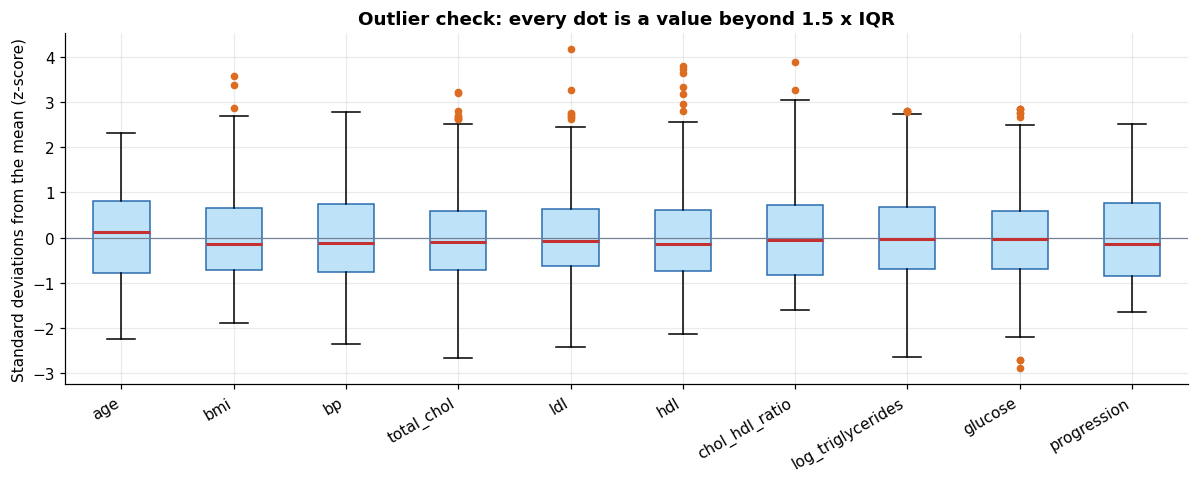

In [8]:
# Visualise: boxplots of z-scores so variables with different units share one axis
z = (clean[measure_cols] - clean[measure_cols].mean()) / clean[measure_cols].std()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.boxplot([z[c] for c in measure_cols], tick_labels=measure_cols, vert=True,
           patch_artist=True, boxprops=dict(facecolor="#bee3f8", color=BLUE),
           medianprops=dict(color=RED, lw=2), flierprops=dict(marker="o", markerfacecolor=ORANGE,
           markeredgecolor=ORANGE, markersize=4))
ax.axhline(0, color=GREY, lw=0.8)
ax.set_ylabel("Standard deviations from the mean (z-score)")
ax.set_title("Outlier check: every dot is a value beyond 1.5 x IQR")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(FIG_DIR / "01_outlier_boxplots.png", bbox_inches="tight")
plt.show()

**Reading the table and the plot**
- 40 individual values are flagged (mostly 0.5-2% of each column) - glucose, total cholesterol, LDL and HDL have the most. `age`, `bp` and `progression` have none.
- The most extreme value sits about 4.2 standard deviations from its mean: unusual, but not impossible.

### Decision: keep the outliers, but flag them
Why not delete them?
1. They are within plausible human ranges (they passed the checks in Step 3c), so they are likely *real patients*, not errors.
2. With only 442 patients, every row is valuable.
3. We test this assumption in Step 7: retraining the model without the flagged patients makes no practical difference.

Instead we add an `n_outlier_flags` column so anyone using the cleaned file can filter them out if they prefer.

In [9]:
# DECISION: keep the outliers, but record them in a transparent flag column.
clean["n_outlier_flags"] = flag_matrix.sum(axis=1).astype(int)

# How extreme are the most-flagged patients? (Sanity check that they are plausible.)
print("Patients by number of flagged variables:")
print(clean["n_outlier_flags"].value_counts().sort_index().to_string())
print()
print("Most extreme z-scores in the whole table:")
print(z.abs().max().sort_values(ascending=False).head(4).round(2).to_string())

Patients by number of flagged variables:
n_outlier_flags
0    411
1     23
2      7
3      1

Most extreme z-scores in the whole table:
ldl               4.17
chol_hdl_ratio    3.89
hdl               3.80
bmi               3.58


## Step 5 - Add helper columns and save the cleaned dataset
We add two easy-to-read grouping columns (`bmi_category`, `age_band`) for the exploratory plots, then write `data/diabetes_clean.csv` and reload it as a sanity check.

In [10]:
# FEATURE ENGINEERING for easier interpretation (not used by the model itself)
# BMI categories follow the standard WHO cut-offs; the few "underweight" patients
# are merged with "healthy" so every group has enough patients to be meaningful.
clean["bmi_category"] = pd.cut(
    clean["bmi"], bins=[0, 25, 30, np.inf], right=False,
    labels=["Healthy (<25)", "Overweight (25-30)", "Obese (30+)"],
)
clean["age_band"] = pd.cut(
    clean["age"], bins=[0, 40, 50, 60, np.inf], right=False,
    labels=["<40", "40-49", "50-59", "60+"],
)

# SAVE the cleaned dataset, then reload it as a self-check
clean.to_csv(DATA_DIR / "diabetes_clean.csv", index=False)
check = pd.read_csv(DATA_DIR / "diabetes_clean.csv")
print(f"Saved data/diabetes_clean.csv -> {check.shape[0]} rows x {check.shape[1]} columns")
print(f"Missing values in saved file: {check.isna().sum().sum()}")
clean.head()

Saved data/diabetes_clean.csv -> 442 rows x 15 columns
Missing values in saved file: 0


,age,sex_code,bmi,bp,total_chol,ldl,hdl,chol_hdl_ratio,log_triglycerides,glucose,progression,sex,n_outlier_flags,bmi_category,age_band
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.86,87,151,Sex code 2,0,Obese (30+),50-59
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.89,69,75,Sex code 1,0,Healthy (<25),40-49
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.67,85,141,Sex code 2,0,Obese (30+),60+
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.89,89,206,Sex code 1,0,Overweight (25-30),<40
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.29,80,135,Sex code 1,0,Healthy (<25),50-59


## Step 6 - Exploratory data analysis (EDA)
Now that the data is trustworthy, we look for patterns. First, numbers; then charts.

In [11]:
# Summary statistics for every numeric variable
summary = clean[measure_cols].describe().T
summary["skew"] = clean[measure_cols].skew()
summary

,count,mean,std,min,25%,50%,75%,max,skew
age,442.0,48.52,13.11,19.00,38.25,50.00,59.00,79.00,-0.23
bmi,442.0,26.38,4.42,18.00,23.20,25.70,29.27,42.20,0.60
bp,442.0,94.65,13.83,62.00,84.00,93.00,105.00,133.00,0.29
total_chol,442.0,189.14,34.61,97.00,164.25,186.00,209.75,301.00,0.38
ldl,442.0,115.44,30.41,41.60,96.05,113.00,134.50,242.40,0.44
hdl,442.0,49.79,12.93,22.00,40.25,48.00,57.75,99.00,0.80
chol_hdl_ratio,442.0,4.07,1.29,2.00,3.00,4.00,5.00,9.09,0.74
log_triglycerides,442.0,4.64,0.52,3.26,4.28,4.62,5.00,6.11,0.29
glucose,442.0,91.26,11.50,58.00,83.25,91.00,98.00,124.00,0.21
progression,442.0,152.13,77.09,25.00,87.00,140.50,211.50,346.00,0.44


In [12]:
# Group comparisons: how many patients, and average progression, per group?
by_bmi = clean.groupby("bmi_category", observed=True)["progression"].agg(["count", "mean", "std"])
by_age = clean.groupby("age_band", observed=True)["progression"].agg(["count", "mean", "std"])
by_sex = clean.groupby("sex", observed=True)["progression"].agg(["count", "mean", "std"])

print("By BMI category:");  print(by_bmi.round(1).to_string()); print()
print("By age band:");      print(by_age.round(1).to_string()); print()
print("By sex code:");      print(by_sex.round(1).to_string())

By BMI category:
                    count   mean   std
bmi_category                          
Healthy (<25)         188  109.3  52.5
Overweight (25-30)    155  165.0  73.0
Obese (30+)            99  213.3  74.5

By age band:
          count   mean   std
age_band                    
<40         117  134.3  69.4
40-49        97  139.6  79.7
50-59       125  163.5  82.4
60+         103  170.4  70.6

By sex code:
            count   mean   std
sex                           
Sex code 1    235  149.0  75.9
Sex code 2    207  155.7  78.5


**Quick reading of the numbers**
- Average progression is about 152 on a scale running from 25 to 346.
- Progression climbs sharply with BMI: roughly 109 (healthy), 165 (overweight), 213 (obese).
- It also rises with age (about 134 for under-40s vs 170 for 60+), but less dramatically.
- The two sex codes are close (149 vs 156), so sex looks like a weak signal on its own.

### Figure 1 - The outcome
The progression score is spread widely, with a mean slightly above the median: a mild right skew, so a few patients progress much more than typical.

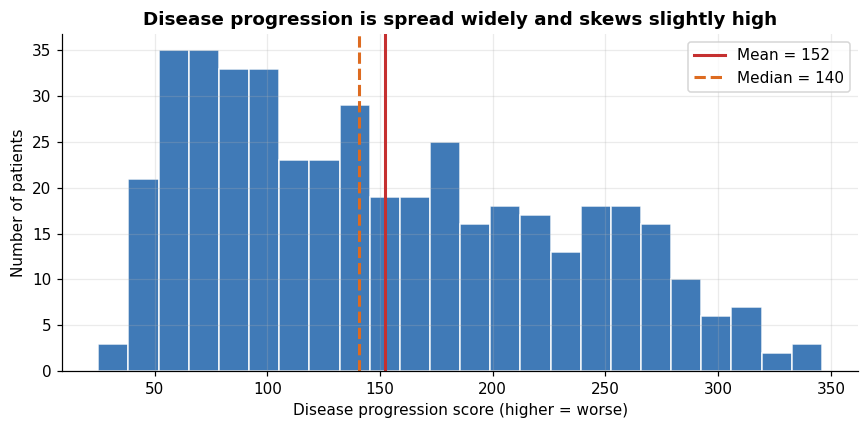

In [13]:
# FIGURE 1 - What does the outcome look like?
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(clean["progression"], bins=24, color=BLUE, edgecolor="white", alpha=0.9)
mean_, median_ = clean["progression"].mean(), clean["progression"].median()
ax.axvline(mean_, color=RED, lw=2, label=f"Mean = {mean_:.0f}")
ax.axvline(median_, color=ORANGE, lw=2, ls="--", label=f"Median = {median_:.0f}")
ax.set_xlabel("Disease progression score (higher = worse)")
ax.set_ylabel("Number of patients")
ax.set_title("Disease progression is spread widely and skews slightly high")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "02_target_distribution.png", bbox_inches="tight")
plt.show()

### Figure 2 - Insight 1: BMI and triglycerides are the strongest single signals
Correlation runs from -1 to +1; the further from 0, the stronger the straight-line link. BMI (+0.59) and log-triglycerides (+0.57) stand out, followed by blood pressure (+0.44) and cholesterol ratio (+0.43). HDL, the "good" cholesterol, is the only clearly *negative* one (-0.39). Sex is essentially unrelated (+0.04).

*Correlation is not causation: these are associations in 442 patients, not proof of cause.*

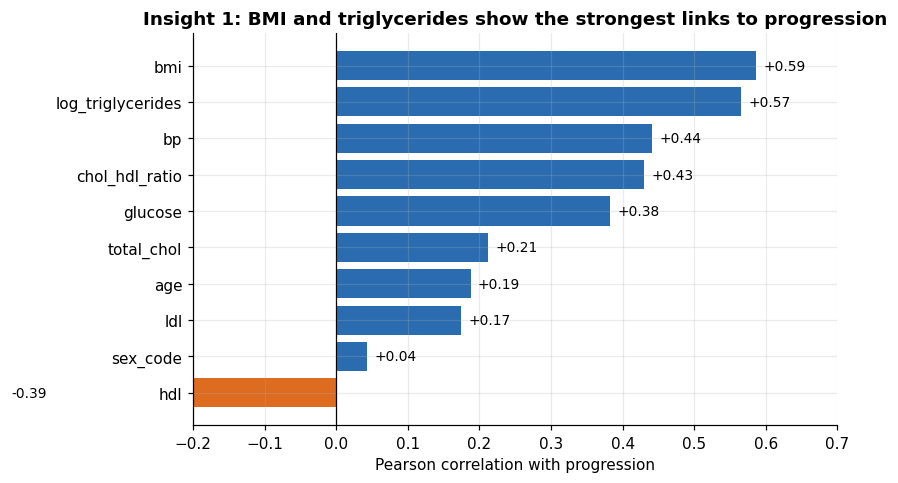

,correlation
bmi,0.59
log_triglycerides,0.57
bp,0.44
chol_hdl_ratio,0.43
glucose,0.38
total_chol,0.21
age,0.19
ldl,0.17
sex_code,0.04
hdl,-0.39


In [14]:
# FIGURE 2 (Insight 1) - Which measurements move together with progression?
predictors = [c for c in measure_cols if c != "progression"] + ["sex_code"]
corr_with_target = clean[predictors + ["progression"]].corr()["progression"].drop("progression")
corr_with_target = corr_with_target.sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [BLUE if v > 0 else ORANGE for v in corr_with_target]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
for i, v in enumerate(corr_with_target.values):
    ax.text(v + (0.01 if v > 0 else -0.01), i, f"{v:+.2f}", va="center",
            ha="left" if v > 0 else "right", fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlim(-0.2, 0.7)
ax.set_xlabel("Pearson correlation with progression")
ax.set_title("Insight 1: BMI and triglycerides show the strongest links to progression")
plt.tight_layout()
fig.savefig(FIG_DIR / "03_correlation_with_target.png", bbox_inches="tight")
plt.show()
corr_with_target.sort_values(ascending=False).round(2).to_frame("correlation")

In [15]:
# Small helper used by the next plots: draw a straight "line of best fit"
def add_trend(ax, x, y, color):
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color=color, lw=2.5)
    return slope

### Figure 3 - Insight 2: Heavier patients progress much further
A clean upward trend: every extra BMI point goes with roughly 10 more progression points. Grouping into categories makes it concrete: obese patients average about twice the progression of healthy-weight patients, and the 95% confidence bars do not come close to overlapping.

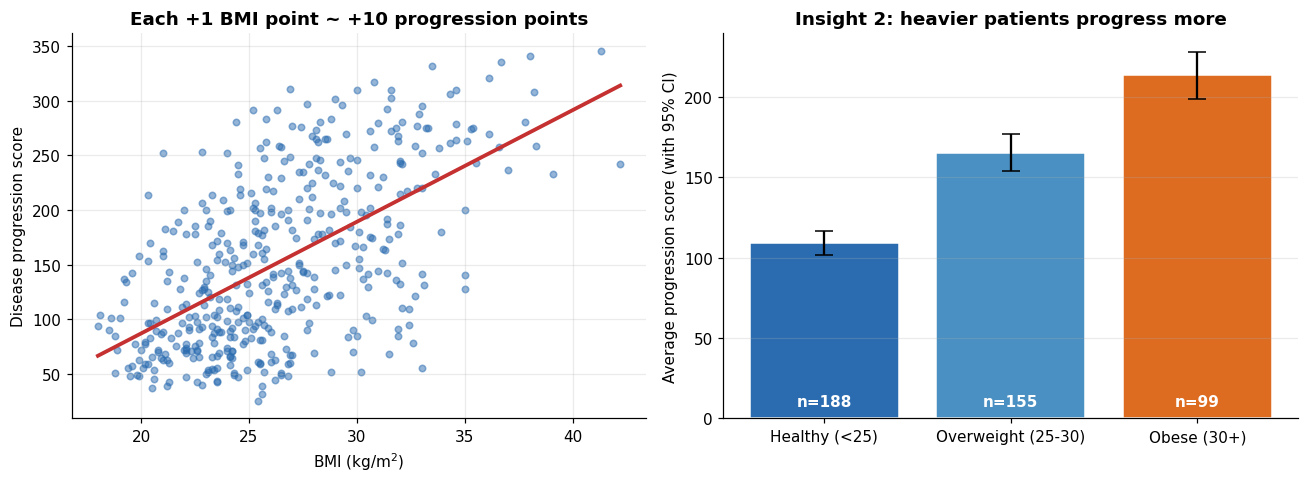

In [16]:
# FIGURE 3 (Insight 2) - BMI vs progression
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: every patient as a dot, plus a trend line
ax = axes[0]
ax.scatter(clean["bmi"], clean["progression"], s=18, alpha=0.5, color=BLUE)
slope = add_trend(ax, clean["bmi"], clean["progression"], RED)
ax.set_xlabel("BMI (kg/m$^2$)")
ax.set_ylabel("Disease progression score")
ax.set_title(f"Each +1 BMI point ~ +{slope:.0f} progression points")

# Right: average progression per BMI category
ax = axes[1]
stats = clean.groupby("bmi_category", observed=True)["progression"].agg(["mean", "sem", "count"])
ax.bar(stats.index.astype(str), stats["mean"], yerr=1.96 * stats["sem"], capsize=6,
       color=[BLUE, "#4a90c2", ORANGE], edgecolor="white")
for i, (m, n) in enumerate(zip(stats["mean"], stats["count"])):
    ax.text(i, 8, f"n={n}", ha="center", color="white", fontweight="bold")
ax.set_ylabel("Average progression score (with 95% CI)")
ax.set_title("Insight 2: heavier patients progress more")
ax.grid(axis="x", visible=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "04_bmi_vs_progression.png", bbox_inches="tight")
plt.show()

### Figure 4 - Insight 3: The blood-fat profile cuts both ways
Higher triglycerides go with *more* progression, higher HDL with *less*. Together with BMI, this suggests a metabolic-health picture rather than one single risk factor.

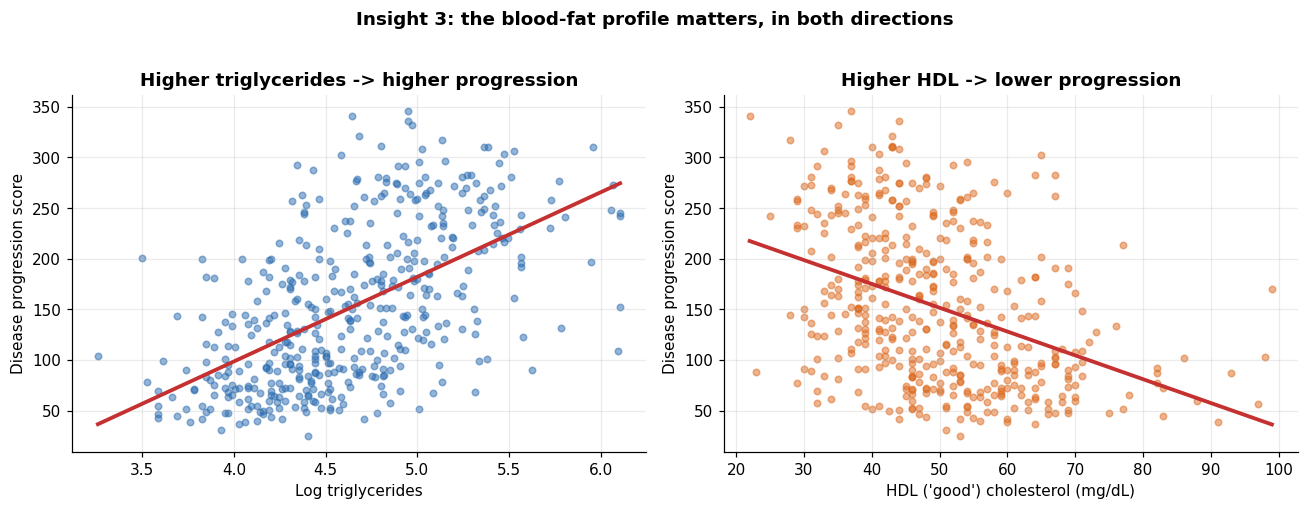

In [17]:
# FIGURE 4 (Insight 3) - Blood-fat measurements and progression
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.scatter(clean["log_triglycerides"], clean["progression"], s=18, alpha=0.5, color=BLUE)
add_trend(ax, clean["log_triglycerides"], clean["progression"], RED)
ax.set_xlabel("Log triglycerides")
ax.set_ylabel("Disease progression score")
ax.set_title("Higher triglycerides -> higher progression")

ax = axes[1]
ax.scatter(clean["hdl"], clean["progression"], s=18, alpha=0.5, color=ORANGE)
add_trend(ax, clean["hdl"], clean["progression"], RED)
ax.set_xlabel("HDL ('good') cholesterol (mg/dL)")
ax.set_ylabel("Disease progression score")
ax.set_title("Higher HDL -> lower progression")

fig.suptitle("Insight 3: the blood-fat profile matters, in both directions", fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "05_lipids_vs_progression.png", bbox_inches="tight")
plt.show()

### Figure 5 - Insight 4: Some predictors are near-duplicates
Total cholesterol and LDL correlate at 0.90, and HDL and the cholesterol ratio at -0.74. When two features carry almost the same information, a model struggles to decide which one deserves the credit. This is called **multicollinearity**, and it matters in Step 7 when we interpret the model's weights.

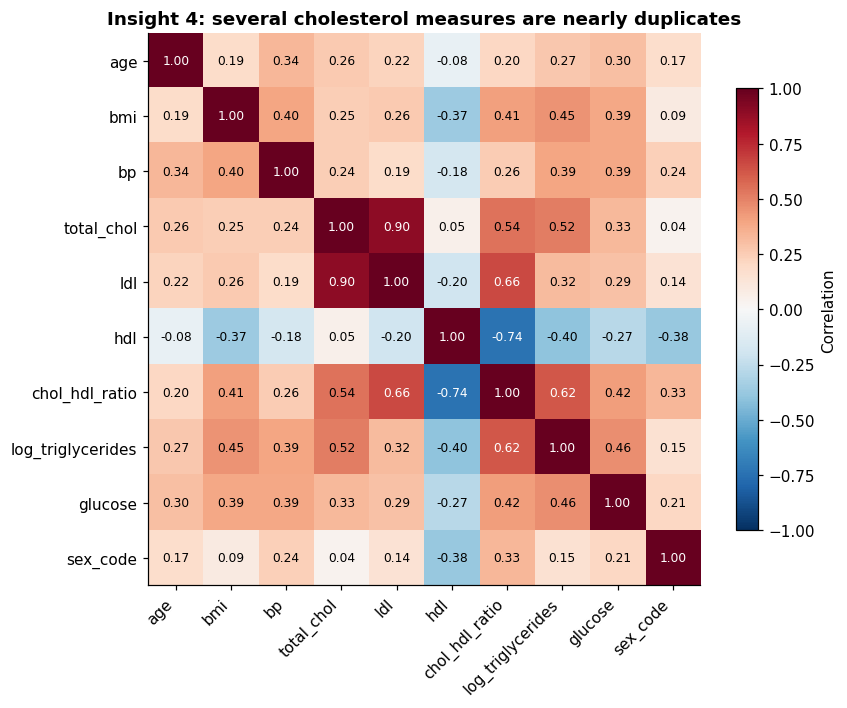

,variable_1,variable_2,correlation
34,total_chol,ldl,0.90
56,hdl,chol_hdl_ratio,-0.74
46,ldl,chol_hdl_ratio,0.66
67,chol_hdl_ratio,log_triglycerides,0.62


In [18]:
# FIGURE 5 (Insight 4) - Do the predictors overlap with each other?
corr = clean[predictors].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.6 else "black")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlation")
ax.set_title("Insight 4: several cholesterol measures are nearly duplicates")
plt.tight_layout()
fig.savefig(FIG_DIR / "06_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# List the most strongly overlapping pairs
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().rename("correlation").reset_index())
pairs.columns = ["variable_1", "variable_2", "correlation"]
pairs.reindex(pairs["correlation"].abs().sort_values(ascending=False).index).head(4).round(2)

### Figure 6 - Age is a real but smaller effect
Median progression increases from the under-40s to the over-60s, but the boxes overlap heavily: age alone cannot predict an individual's outcome.

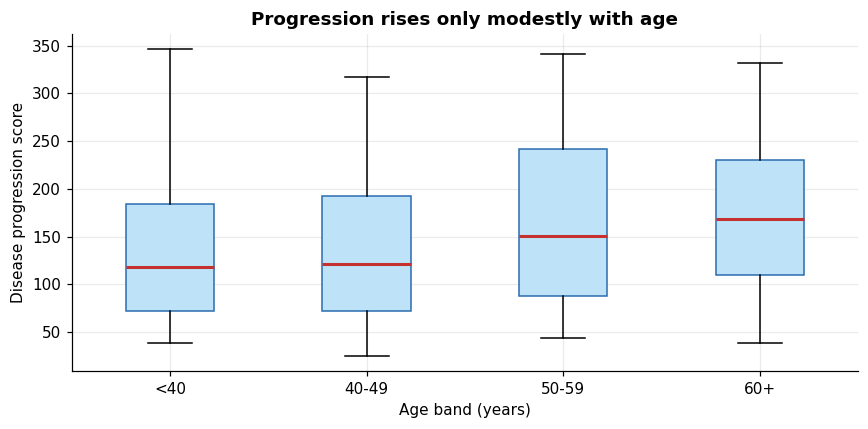

In [19]:
# FIGURE 6 - Age and progression (a smaller effect than BMI or triglycerides)
fig, ax = plt.subplots(figsize=(8, 4))
groups = [clean.loc[clean["age_band"] == b, "progression"] for b in clean["age_band"].cat.categories]
ax.boxplot(groups, tick_labels=clean["age_band"].cat.categories, patch_artist=True,
           boxprops=dict(facecolor="#bee3f8", color=BLUE), medianprops=dict(color=RED, lw=2),
           flierprops=dict(marker="o", markerfacecolor=ORANGE, markeredgecolor=ORANGE, markersize=4))
ax.set_xlabel("Age band (years)")
ax.set_ylabel("Disease progression score")
ax.set_title("Progression rises only modestly with age")
plt.tight_layout()
fig.savefig(FIG_DIR / "07_age_band_boxplot.png", bbox_inches="tight")
plt.show()

## Step 7 - A lightweight machine-learning model
### Choosing the model type
The outcome is a **number** (the progression score), so this is a **regression** problem (classification would need categories, clustering has no target). EDA showed mostly straight-line relationships, so **linear regression** is a natural, easy-to-explain fit.

### Plan
1. Split patients into **training** (80%) and **test** (20%) sets - the test set simulates *new* patients.
2. Compare three models: a do-nothing **baseline**, **linear regression**, and **ridge regression** (a linear model that damps the effect of overlapping features).
3. Judge them with cross-validation plus the held-out test set.

In [20]:
# MODEL SETUP
# Task: REGRESSION - predict the numeric progression score from the 10 baseline measurements.
FEATURES = ["age", "sex_code", "bmi", "bp", "total_chol", "ldl", "hdl",
            "chol_hdl_ratio", "log_triglycerides", "glucose"]
X = clean[FEATURES]
y = clean["progression"]

# Hold out 20% of patients as a TEST set the model never sees while learning.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Training patients: {len(X_train)}  |  Test patients: {len(X_test)}")

Training patients: 353  |  Test patients: 89


In [21]:
# THREE MODELS, from simplest to slightly smarter. Each is a "pipeline":
#   impute (safety net) -> standardise (put all features on the same scale) -> model
models = {
    # 1) Baseline: always predicts the average progression. Any useful model must beat this.
    "Baseline (always the mean)": make_pipeline(
        SimpleImputer(strategy="median"), DummyRegressor(strategy="mean")),

    # 2) Linear regression: progression = intercept + sum(weight x feature)
    "Linear regression": make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(), LinearRegression()),

    # 3) Ridge regression: same idea, but shrinks the weights. Helps when features
    #    overlap (see Insight 4). RidgeCV picks the shrinkage strength automatically.
    "Ridge regression": make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        RidgeCV(alphas=np.logspace(-2, 3, 30))),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in models.items():
    # Cross-validation on the TRAINING data: a more stable estimate of performance
    cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2")
    # Fit on all training data, then score once on the untouched TEST data
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({
        "model": name,
        "CV R2 (mean)": cv_r2.mean(),
        "CV R2 (std)": cv_r2.std(),
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test R2": r2_score(y_test, pred),
    })

results = pd.DataFrame(rows).set_index("model")
results.round(2)

,CV R2 (mean),CV R2 (std),Test MAE,Test RMSE,Test R2
model,,,,,
Baseline (always the mean),-0.03,0.02,64.01,73.22,-0.01
Linear regression,0.48,0.04,42.79,53.85,0.45
Ridge regression,0.48,0.04,42.81,53.77,0.45


### Metrics explained
| Metric | Meaning | Good is... |
|---|---|---|
| **MAE** (mean absolute error) | Average miss, in progression points | lower |
| **RMSE** | Like MAE but punishes big misses more | lower |
| **R2** | Share of the outcome's variation the model explains (0 = no better than guessing the average, 1 = perfect) | higher |
| **CV R2** | R2 averaged over 5 re-shuffled train/validation splits - a steadier estimate | higher |

### Reading the results (plain language)
- The **baseline** (always guess the average) scores an R2 of about 0 and is off by roughly 64 points on average. Any real model must beat that.
- **Linear and ridge regression are almost identical**: R2 about 0.45 on the test set and about 0.48 in cross-validation, with typical errors of about 43 points. Ridge gives no measurable gain here, so either is fine; both tell the same story.
- In everyday terms: the model explains **about 45% of why patients differ** and cuts the typical error by roughly **one third** compared with guessing the average. That is a meaningful but modest improvement: a typical prediction is still off by about 43 points on a scale where patients spread over ~25-346.

In [22]:
# Put the numbers in context
best = models["Ridge regression"]
pred = best.predict(X_test)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
base_mae = results.loc["Baseline (always the mean)", "Test MAE"]

print(f"Spread of the real outcome (std)     : {y_test.std():.0f} points")
print(f"Baseline typical error (MAE)         : {base_mae:.0f} points")
print(f"Ridge typical error (MAE)            : {mae:.0f} points  ({100 * (1 - mae / base_mae):.0f}% smaller)")
print(f"Share of variation explained (R2)    : {100 * r2:.0f}%")
print(f"Ridge shrinkage strength chosen (alpha): {best[-1].alpha_:.2f}")

Spread of the real outcome (std)     : 73 points
Baseline typical error (MAE)         : 64 points
Ridge typical error (MAE)            : 43 points  (33% smaller)
Share of variation explained (R2)    : 45%
Ridge shrinkage strength chosen (alpha): 1.17


In [23]:
# ROBUSTNESS CHECK for our Step 4 decision: does keeping the outliers hurt the model?
# Retrain WITHOUT the flagged patients, but score on the SAME test patients as before.
keep = X_train.index.isin(clean.index[clean["n_outlier_flags"] == 0])
no_outlier_model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30)))
no_outlier_model.fit(X_train[keep], y_train[keep])
alt_pred = no_outlier_model.predict(X_test)

print(f"Trained on all {len(X_train)} patients      -> test R2 = {r2:.3f}, MAE = {mae:.1f}")
print(f"Trained without flagged ({keep.sum()} patients) -> test R2 = {r2_score(y_test, alt_pred):.3f}, "
      f"MAE = {mean_absolute_error(y_test, alt_pred):.1f}")
print("-> Practically identical, so keeping the outliers was a safe choice.")

Trained on all 353 patients      -> test R2 = 0.454, MAE = 42.8
Trained without flagged (326 patients) -> test R2 = 0.456, MAE = 42.7
-> Practically identical, so keeping the outliers was a safe choice.


### Figure 7 - Predicted vs actual
Points would sit on the dashed line if predictions were perfect. They follow it in general but with plenty of scatter, and the model tends to **under-predict the highest scores and over-predict the lowest** (the usual 'pull towards the average' of a simple model). The error histogram is centred near zero (no systematic bias) but wide.

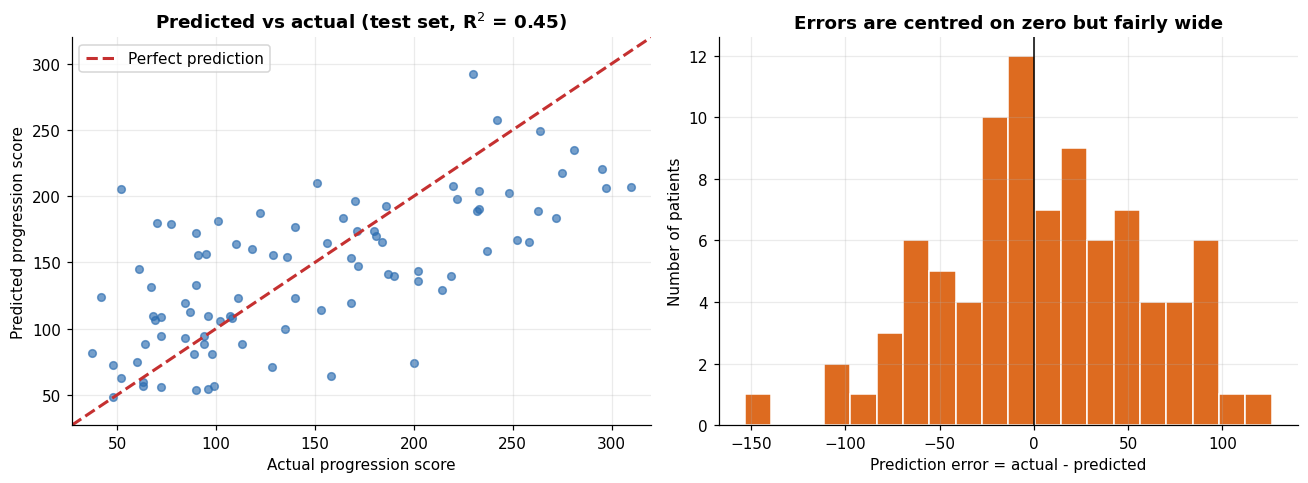

In [24]:
# FIGURE 7 - How good are the predictions?
residuals = y_test - pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.scatter(y_test, pred, s=25, alpha=0.65, color=BLUE)
lims = [min(y_test.min(), pred.min()) - 10, max(y_test.max(), pred.max()) + 10]
ax.plot(lims, lims, color=RED, lw=2, ls="--", label="Perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual progression score")
ax.set_ylabel("Predicted progression score")
ax.set_title(f"Predicted vs actual (test set, R$^2$ = {r2:.2f})")
ax.legend()

ax = axes[1]
ax.hist(residuals, bins=20, color=ORANGE, edgecolor="white")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Prediction error = actual - predicted")
ax.set_ylabel("Number of patients")
ax.set_title("Errors are centred on zero but fairly wide")

plt.tight_layout()
fig.savefig(FIG_DIR / "08_model_performance.png", bbox_inches="tight")
plt.show()

### Figure 8 - What did the model learn?
Triglycerides, BMI and blood pressure carry positive weights, matching the EDA. But look at `total_chol` (strongly negative) and `ldl` (positive): this is the **multicollinearity** from Insight 4. Because those two measure nearly the same thing, the model splits the credit in opposite directions. **Lesson: do not read individual weights of overlapping features as 'cause and effect'.** Prefer the EDA correlations and the model's *overall* accuracy.

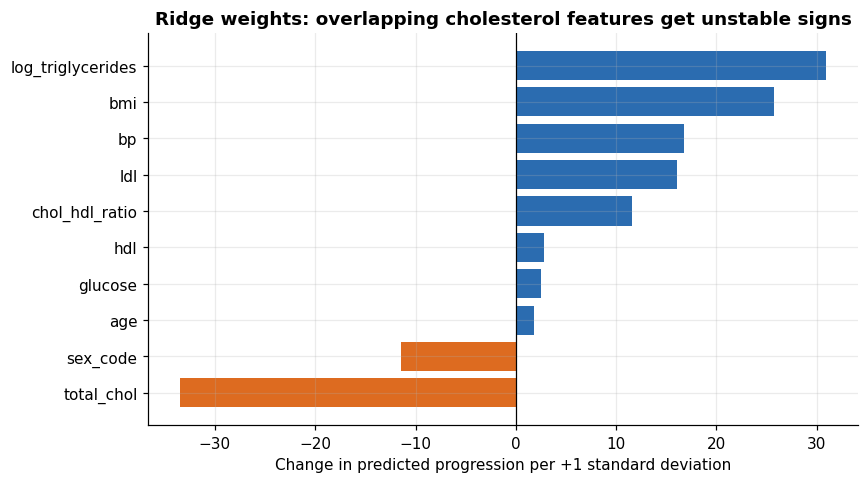

,weight
log_triglycerides,30.9
bmi,25.7
bp,16.7
ldl,16.1
chol_hdl_ratio,11.6
hdl,2.8
glucose,2.5
age,1.8
sex_code,-11.4
total_chol,-33.4


In [25]:
# FIGURE 8 - What did the model learn?
# Because features were standardised, weights are comparable: each shows the change in
# predicted progression for a "one standard deviation" increase in that feature.
coefs = pd.Series(best[-1].coef_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(coefs.index, coefs.values, color=[BLUE if v > 0 else ORANGE for v in coefs])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Change in predicted progression per +1 standard deviation")
ax.set_title("Ridge weights: overlapping cholesterol features get unstable signs")
plt.tight_layout()
fig.savefig(FIG_DIR / "09_model_coefficients.png", bbox_inches="tight")
plt.show()
coefs.sort_values(ascending=False).round(1).to_frame("weight")

## Step 8 - Conclusions and limitations
### Key findings
1. **BMI and triglycerides** are the strongest single signals of progression; patients with obesity average about 2x the score of healthy-weight patients.
2. **HDL cholesterol** is protective (negative association); **age** matters modestly; **sex** barely at all.
3. Several cholesterol measures overlap heavily, so individual model weights are unreliable.
4. A simple linear model explains **~45%** of the variation and cuts typical error by ~**33%** versus a baseline: useful for a first screening-style estimate, far from precise.

### Limitations
- **Small sample** (442) from one study; results may not generalise to other populations.
- **Linear model only** - relationships that bend or interact are missed.
- **Association, not causation**; and the sex coding is undocumented.
- Numbers quoted in the text come from a run with `RANDOM_STATE = 42`; other library versions can shift them slightly.

### Ideas to extend
- Try a Random Forest or Gradient Boosting model and compare R2.
- Turn the target into *high / low* progression and build a classifier (report precision/recall).
- Use PCA or drop one of the overlapping cholesterol features and re-check the weights.
- Swap in the Pima Indians Diabetes dataset (which hides missing values as zeros) to practise heavier cleaning with this same notebook structure.